<a href="https://colab.research.google.com/github/cinth90/deeplearning/blob/main/ProyectoDSIII%2BDebenedetto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------------------------------------------
##**PROYECTO FINAL - ANÁLISIS DE COMENTARIOS DEL RESORT DAYDREAM ISLAND**

--------------------------------------------------------------------------------

**Estudiante:** Cinthia Debenedetto

**Escuela:** Coderhouse

**Curso:** Data Science III: NLP & Deep Learning aplicado a Ciencia de Datos

**Comisión:** 77805

**Profesor:** Ezequiel Juan Bassano

## **1. PROBLEMA DE NEGOCIO**: Optimización de la Experiencia del Huésped

En la industria hotelera de lujo, la reputación y la fidelización de los clientes dependen de la calidad del servicio y la infraestructura percibida. Con el auge de las plataformas de reservas online, los huéspedes generan constantemente grandes volúmenes de datos no estructurados en forma de comentarios sobre lo que "les gustó" y lo que "no les gustó" de su estadía.

Sin embargo, el procesamiento de esta información presenta varios desafíos:

* Volumen y Fragmentación: La cantidad de reseñas diarias hace que el análisis manual sea ineficiente, impidiendo una respuesta ágil a las fallas detectadas.

* Ambigüedad y Sentimientos Mixtos: Un mismo huésped puede expresar una satisfacción alta con la ubicación pero una crítica severa sobre la limpieza o el mantenimiento, lo que requiere una separación precisa de las temáticas para no sesgar el diagnóstico.

* Identificación de Patrones Críticos: Sin herramientas automatizadas, resulta complejo detectar si un problema (como el ruido en las duchas o la falta de variedad en el desayuno) es un evento aislado o una deficiencia sistémica que requiere inversión de capital.

La falta de una interpretación sistemática de estos datos genera una brecha entre la percepción del huésped y las decisiones operativas de la gerencia, poniendo en riesgo la competitividad del resort en un mercado tan exigente como el turismo de las Islas Whitsunday.

## **2. OBJETIVO GENERAL**

Desarrollar y comparar modelos de Machine Learning y Deep Learning, integrando técnicas avanzadas de Procesamiento de Lenguaje Natural (NLP), para la clasificación y análisis automatizado de las reseñas de los huéspedes de Daydream Island Resort. Con esto, se busca transformar grandes volúmenes de texto no estructurado en métricas accionables que permitan identificar áreas críticas de mejora operativa, optimizar la experiencia del cliente y facilitar la toma de decisiones estratégicas basadas en evidencia cualitativa dentro del sector turístico.

## **3. ORIGEN DE LOS DATOS**

El dataset utilizado en el presente proyecto fue generado mediante técnicas de Web Scraping aplicadas al sitio web de Booking.com, una de las plataformas de agregación de servicios de viaje y alojamiento más importantes a nivel global. Los datos fueron extraídos específicamente del perfil del Daydream Island Resort, capturando la experiencia de huéspedes internacionales durante diversos períodos de tiempo.

La estructura del dataset se caracteriza por los siguientes puntos:

Naturaleza de la información: Contiene datos tanto cuantitativos (puntajes numéricos) como cualitativos (textos de reseñas), lo que permite un análisis multidimensional del sentimiento del cliente.

Segmentación del discurso: A diferencia de otros datasets de sentimiento general, este cuenta con una separación nativa entre secciones de "Me gustó" (aspectos positivos) y "No me gustó" (puntos de dolor), lo cual facilita el etiquetado y entrenamiento de los modelos de clasificación.

Diversidad lingüística y demográfica: Al ser un destino internacional, el dataset presenta reseñas principalmente en español e inglés, incluyendo metadatos como el país de procedencia del viajero, el tipo de habitación reservada y la duración de la estadía.

La información proviene directamente de usuarios verificados por la plataforma, lo que garantiza que los textos reflejan experiencias reales de consumo en el resort.









## **4. DEFINICIÓN DE VARIABLES**

El dataset resultante del procesamiento y limpieza de datos está compuesto por variables tanto categóricas (texto y etiquetas) como numéricas (puntajes), las cuales se definen de la siguiente manera:

Comentario: Cadena de texto que contiene la opinión específica del huésped sobre su experiencia en el resort. Representa la unidad de análisis para las técnicas de NLP.

Tipo de comentario: Variable categórica que clasifica el texto en dos sentimientos predefinidos:

Me gustó: Representa percepciones positivas, fortalezas del servicio o satisfacciones del cliente.

No me gustó: Representa puntos de dolor, quejas o áreas de mejora identificadas por el huésped.

Puntaje (Variable Numérica): Valor decimal (en escala de 1 a 10) que indica la satisfacción general del usuario, proporcionando una referencia cuantitativa que complementa el análisis de sentimiento textual.

Metadatos Contextuales: Variables adicionales que permiten segmentar el análisis, tales como:

País procedencia: Origen geográfico del huésped.

Tipo de habitación: Categoría del alojamiento reservado.

Tipo viajero: Clasificación del grupo (En pareja, En familia, Solo, etc.).

## **5. LIBRERÍAS A UTILIZAR**

### **5.1. IMPORTACIÓN DE LIBRERÍAS** ###

In [115]:
  # Manipulación, análisis y visualización de datos
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

  # Entrada y detección de codificación de archivos de texto
import chardet

  # Procesamiento del lenguaje natural (NLP)
import re
import spacy
import nltk
import ast
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import TreebankWordTokenizer

  # Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score,classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

  # Deep Learning
import random
import os
import keras
from keras import layers
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist, cifar10, cifar100, fashion_mnist
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

### **5.2. DESCARGA DE RECURSOS NLTK PARA NLP** ###

In [116]:
# Tokenizadores de texto
nltk.download('punkt')
nltk.download('punkt_tab')

# Lista de stopwords
nltk.download('stopwords')

# Diccionario para lematización
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## **6. CARGA & LECTURA DE DATOS** ##

Se procede a cargar y leer el dataset desde un drive.

In [117]:
url = 'https://drive.google.com/uc?id=1CcGo-GsQ_E_nC2SXE0NH_V6-O6foK1j6&export=download'
df = pd.read_csv(url)
df.head()

,Titulo del comentario,Tipo de Habitacion,Fecha reserva,Fecha del comentario,Nombre,Me gusto,No me gusto,Duracion estadia,Puntaje,Pais procedencia,Tipo viajero
0,"Muy lindo , volvería !",Alojamiento Superior con cama extragrande y vi...,enero de 2026,Fecha del comentario: 6 de enero de 2026,Javiera,"La Isla y el resort muy lindos, solo 30 minuto...",Podría haber más variedad en la comida de los ...,3 noches ·,"8,0",Chile,En pareja
1,Agradable,Deluxe Ocean Terrace King - Inclusive of Retur...,diciembre de 2025,Fecha del comentario: 28 de diciembre de 2025,Blanco,La ubicación,"Está muy viejo, necesita una reforma con urgen...",4 noches ·,"6,0",España,En pareja
2,Normal,Alojamiento Superior con cama extragrande y vi...,septiembre de 2025,Fecha del comentario: 1 de octubre de 2025,Cristina,Me gustó las actividades que tenia. aunque el ...,Me defraudó bastante en desayuno para ser un h...,3 noches ·,"6,0",España,En pareja
3,agradable y tranquila,Habitación Doble Resort con cama grande,febrero de 2025,Fecha del comentario: 24 de febrero de 2025,Marco,"el desayuno es bueno, buffet con diversas opci...","no hay opción de restaurantes a elegir, en el ...",2 noches ·,"8,0",España,En pareja
4,Bueno pero no tan bueno,Habitación Deluxe Ocean con terraza - Cama ext...,enero de 2025,Fecha del comentario: 24 de enero de 2025,Claudia,La ubicación,La limpieza es lo peor del lugar. Y el servici...,6 noches ·,"6,0",Argentina,En familia


Como los comentarios estan divididos en dos columnas(me gusto y no me gusto) lo que se hizo fue crear una nueva columna llamada comentario para poder llevar a cabo el analisis.

In [118]:
#Identifico las columnas que NO quiero mover (las que identifican al registro)
columnas_id = [col for col in df.columns if col not in ['Me gusto', 'No me gusto']]

#Aplico la función melt para separar "Me gusto" y "No me gusto" en filas
df_separado = pd.melt(
    df,
    id_vars=columnas_id,
    value_vars=['Me gusto', 'No me gusto'],
    var_name='Tipo de comentario',
    value_name='Comentario'
)

# Ordeno para que los comentarios de la misma persona queden juntos
df_separado = df_separado.sort_values(by=columnas_id).reset_index(drop=True)

In [119]:
df=df_separado

In [120]:
df.head()

,Titulo del comentario,Tipo de Habitacion,Fecha reserva,Fecha del comentario,Nombre,Duracion estadia,Puntaje,Pais procedencia,Tipo viajero,Tipo de comentario,Comentario
0,"""It Was a Daydream, And We Can’t Still Wake Up...",Superior Ocean View King– Including Return Fer...,abril de 2024,Fecha del comentario: 7 de abril de 2024,Fred,1 noche ·,10,Australia,En pareja,Me gusto,"Amazing , kind and very informative Staff . Am..."
1,"""It Was a Daydream, And We Can’t Still Wake Up...",Superior Ocean View King– Including Return Fer...,abril de 2024,Fecha del comentario: 7 de abril de 2024,Fred,1 noche ·,10,Australia,En pareja,No me gusto,Services the ambiance the food . Everything wa...
2,2 nights in paradise,Serenity King Suite,mayo de 2025,Fecha del comentario: 15 de mayo de 2025,Peter,2 noches ·,10,Australia,En pareja,Me gusto,Loved the the trip it was great. Unfortunately...
3,2 nights in paradise,Serenity King Suite,mayo de 2025,Fecha del comentario: 15 de mayo de 2025,Peter,2 noches ·,10,Australia,En pareja,No me gusto,For me the only downside was that we checked o...
4,3 days was perfect,Alojamiento Superior con cama extragrande y vi...,septiembre de 2023,Fecha del comentario: 5 de octubre de 2023,Pauline,3 noches ·,"7,0",Australia,En familia,Me gusto,"Breakfast buffet, wildlife,"


# Analisis exploratorio de datos

**Analisis por regiones de procedencia de los huspedes**

                     Region  Puntaje Promedio  Cantidad de Comentarios
1                      Asia            8.1429                       56
3                    Europa            7.8090                      534
2  Australia, NZ y Pacífico            7.6594                     3482
0                    Africa            7.6364                       22
5              Norteamérica            7.2727                       44
4                     LATAM            6.8636                       44


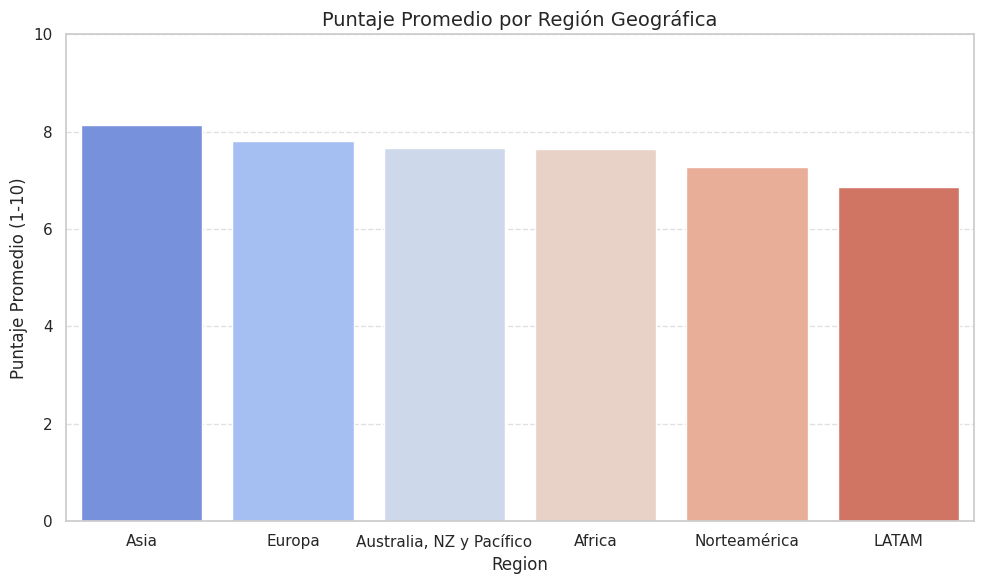

In [121]:
df['Puntaje_num'] = df['Puntaje'].str.replace(',', '.').astype(float)


mapping = {
    # Australia, NZ e Islas del Pacífico cercanas
    'Australia': 'Australia, NZ y Pacífico',
    'Nueva Zelanda': 'Australia, NZ y Pacífico',
    'Islas Cook': 'Australia, NZ y Pacífico',

    # Norteamérica
    'Estados Unidos': 'Norteamérica',
    'Canadá': 'Norteamérica',

    # LATAM
    'Argentina': 'LATAM', 'Chile': 'LATAM', 'Guatemala': 'LATAM', 'Brasil': 'LATAM',
    'Perú': 'LATAM', 'México': 'LATAM', 'Colombia': 'LATAM',

    # Europa
    'Hungría': 'Europa', 'Rumanía': 'Europa', 'Portugal': 'Europa', 'Letonia': 'Europa',
    'Bélgica': 'Europa', 'Países Bajos': 'Europa', 'Polonia': 'Europa', 'Eslovaquia': 'Europa',
    'Francia': 'Europa', 'Italia': 'Europa', 'Reino Unido': 'Europa', 'Alemania': 'Europa',
    'Suiza': 'Europa', 'Grecia': 'Europa', 'Austria': 'Europa', 'Noruega': 'Europa',
    'Dinamarca': 'Europa', 'Finlandia': 'Europa', 'Suecia': 'Europa', 'Irlanda': 'Europa',
    'Guernsey': 'Europa', 'España': 'Europa',

    # Asia
    'Filipinas': 'Asia', 'Mongolia': 'Asia', 'Indonesia': 'Asia', 'Israel': 'Asia',
    'Malasia': 'Asia', 'India': 'Asia', 'China': 'Asia', 'Japón': 'Asia',
    'Kazajistán': 'Asia', 'Kirguizistán': 'Asia', 'Sri Lanka': 'Asia', 'Arabia Saudí': 'Asia',

    # Africa
    'Isla Mauricio': 'Africa', 'Kenia': 'Africa', 'Sudáfrica': 'Africa'
}

df['Region'] = df['Pais procedencia'].map(mapping).fillna('Otros')
df_filtrado = df[df['Region'] != 'Otros'].copy()

# Group by Region
resumen_region = df_filtrado.groupby('Region')['Puntaje_num'].agg(['mean', 'count']).reset_index()
resumen_region.columns = ['Region', 'Puntaje Promedio', 'Cantidad de Comentarios']
resumen_region = resumen_region.sort_values(by='Puntaje Promedio', ascending=False)

#Grafico
plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_region, x='Region', y='Puntaje Promedio', palette='coolwarm',hue= 'Region', legend=False)

plt.title('Puntaje Promedio por Región Geográfica', fontsize=14)
plt.ylabel('Puntaje Promedio (1-10)', fontsize=12)
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()


df.to_csv('daydream_booking_regiones_v2.csv', index=False)

print(resumen_region)

Resumen de satisfacción por Región:
* Asia (8.14): Lidera como la región con mayor satisfacción promedio.
* Europa (7.81): Se mantiene en segundo lugar con una valoración muy alta.
* Australia, NZ y Pacífico (7.66): El bloque principal del resort muestra una satisfacción sólida y estable.
* Africa (7.64): Prácticamente empatado con la región de Oceanía en niveles de satisfacción.
* Norteamérica (7.27): Presenta una valoración positiva.
* LATAM (6.86): Es la región que reporta la menor satisfacción promedio en el dataset.

  Tipo viajero  Estadia_noches  Puntaje_num
0   En familia               1       7.9224
1   En familia               2       7.9573
2   En familia               3       7.4416
3   En familia               4       7.3333
4   En familia               5       7.1089
5   En familia               6       6.8837
6   En familia               7       7.2600
7   En familia               8       6.6429
8   En familia               9       6.2500
9   En familia              10       6.6000

Conteo por tipo de viajero:
Tipo viajero
En pareja                 1844
En familia                1816
En grupo                   338
Persona que viaja sola     194
Name: count, dtype: int64


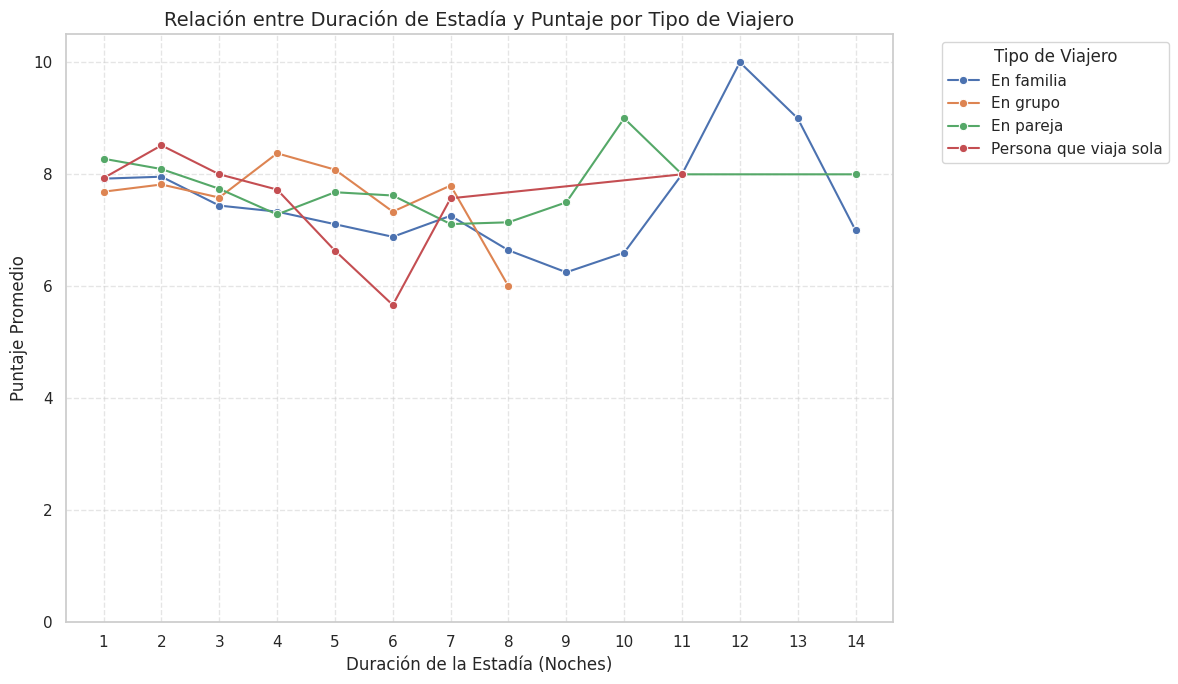

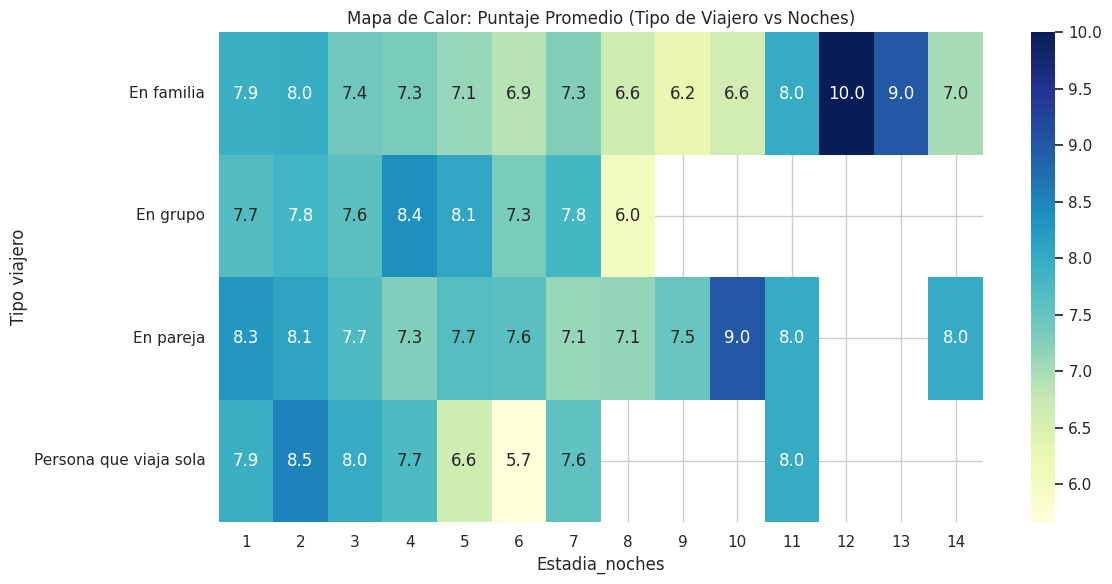

In [122]:
# Limpio 'Duracion estadia' para extraer el numero de noches
# Ejemplo: "3 noches ·" -> 3
def extract_nights(text):
    if pd.isna(text):
        return None
    match = re.search(r'(\d+)', str(text))
    return int(match.group(1)) if match else None

df['Estadia_noches'] = df['Duracion estadia'].apply(extract_nights)

#Group by 'Tipo viajero' y 'Estadia_noches'
resumen_viajero_estadia = df.groupby(['Tipo viajero', 'Estadia_noches'])['Puntaje_num'].mean().reset_index()

#Grafico: Line plot (Puntaje vs durecion y Tipo viajero)
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(data=resumen_viajero_estadia, x='Estadia_noches', y='Puntaje_num', hue='Tipo viajero', marker='o', ax=ax)

ax.set_title('Relación entre Duración de Estadía y Puntaje por Tipo de Viajero', fontsize=14)
ax.set_xlabel('Duración de la Estadía (Noches)', fontsize=12)
ax.set_ylabel('Puntaje Promedio', fontsize=12)
ax.set_ylim(0, 10.5)
ax.set_xticks(sorted(df['Estadia_noches'].dropna().unique()))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Tipo de Viajero', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()


#Mapa de calor Puntaje, Tipo de viajero y duracion estadia
pivot_table = df.pivot_table(index='Tipo viajero', columns='Estadia_noches', values='Puntaje_num', aggfunc='mean')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set_title('Mapa de Calor: Puntaje Promedio (Tipo de Viajero vs Noches)')
plt.tight_layout()

print(resumen_viajero_estadia.head(10))
print("\nConteo por tipo de viajero:")
print(df['Tipo viajero'].value_counts())

Observaciones clave del análisis:
1. Tendencia General: En casi todos los tipos de viajeros, se observa que las
estadías cortas (1 a 3 noches) suelen tener puntajes más altos y estables. A medida que la estadía se prolonga (especialmente entre las 5 y 9 noches), el puntaje promedio tiende a descender levemente, lo que podría indicar que el desgaste de las instalaciones o la falta de variedad en actividades impacta más en estadías largas.
2. Viajeros Solos: Presentan una caída notable de satisfacción en estadías de 6 noches (5.7), sugiriendo que el resort podría estar más orientado a grupos o parejas que a personas individuales para estancias prolongadas.
3. Familias: Mantienen una satisfacción bastante constante, aunque con una ligera baja hacia la semana de estadía (6.9 en la noche 6), recuperándose en estadías muy largas, donde probablemente la comodidad de la habitación se vuelve el factor principal.
4. Parejas: Es el grupo más numeroso (922 registros) y muestra la mayor estabilidad, manteniéndose mayormente por encima del 7.5 independientemente de la duración

Últimos meses procesados:
    Mes_Año  Puntaje_num Mes_Año_str
31  2025-12       7.1475     2025-12
32  2026-01       6.6517     2026-01
33  2026-02       7.9574     2026-02
34  2026-03       7.7353     2026-03
35  2026-04       7.5000     2026-04

Registros eliminados: 0


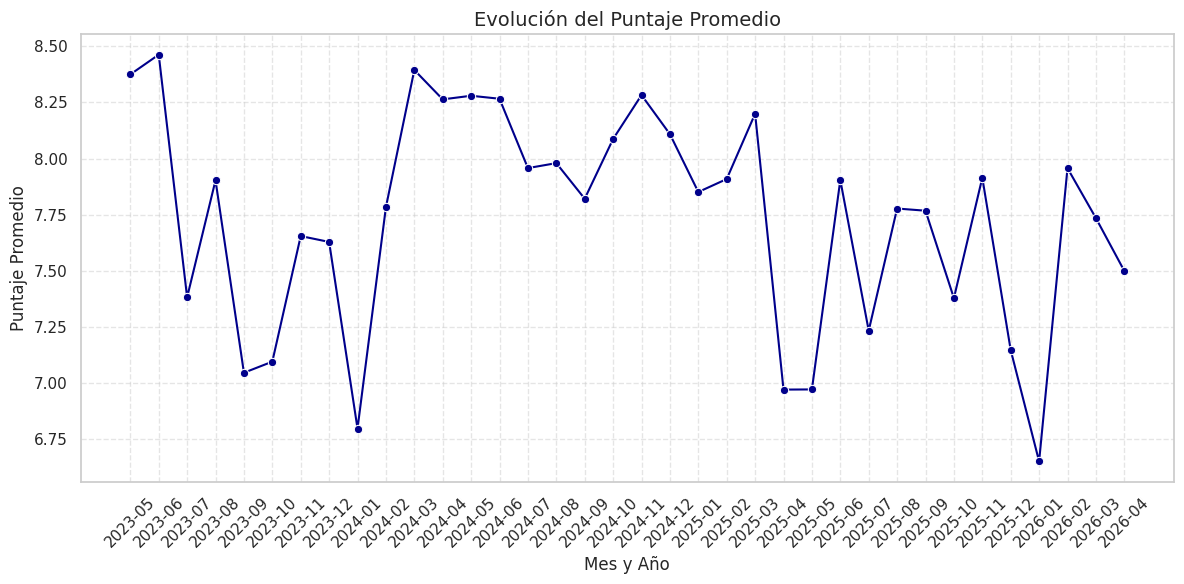

In [123]:
def clean_comment_date(text):
    if pd.isna(text): return None
    text = text.replace('Fecha del comentario:', '').strip()
    meses = {
        'enero': 'January', 'febrero': 'February', 'marzo': 'March', 'abril': 'April',
        'mayo': 'May', 'junio': 'June', 'julio': 'July', 'agosto': 'August',
        'septiembre': 'September', 'octubre': 'October', 'noviembre': 'November', 'diciembre': 'December'
    }
    for es, en in meses.items():
        text = text.replace(es, en)
    try:
        return pd.to_datetime(text, format='%d de %B de %Y')
    except:
        return None

df['Fecha_limpia'] = df['Fecha del comentario'].apply(clean_comment_date)

# Filtrar: Descartar mayo de 2026
# Condición: Fecha no es mayo de 2026
df_filtrado = df[~((df['Fecha_limpia'].dt.year == 2026) & (df['Fecha_limpia'].dt.month == 5))].copy()

df=df_filtrado

# Re-generar la evolución temporal para ver el impacto
df_time = df.dropna(subset=['Fecha_limpia']).copy()
df_time['Mes_Año'] = df_time['Fecha_limpia'].dt.to_period('M')
evolucion_temp = df_time.groupby('Mes_Año')['Puntaje_num'].mean().reset_index()
evolucion_temp['Mes_Año_str'] = evolucion_temp['Mes_Año'].astype(str)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=evolucion_temp, x='Mes_Año_str', y='Puntaje_num', marker='o', color='darkblue', ax=ax)

ax.set_title('Evolución del Puntaje Promedio', fontsize=14)
ax.set_xlabel('Mes y Año', fontsize=12)
ax.set_ylabel('Puntaje Promedio', fontsize=12)
plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()


# Mostrar los últimos registros para confirmar el descarte
print("Últimos meses procesados:")
print(evolucion_temp.tail(5))
print(f"\nRegistros eliminados: {len(df) - len(df_filtrado)}")

**Hallazgos de la evolución temporal:**
* Ciclicidad y Variabilidad: Se observa una fluctuación constante en el puntaje promedio a lo largo de los meses. Por ejemplo, a principios de 2024 (febrero/marzo) hubo picos de satisfacción cercanos al 8.4, mientras que en otros periodos como enero de 2024 el puntaje bajó a 6.8.

* Tendencia Reciente: Hacia finales de 2025 y principios de 2026, se nota una volatilidad marcada. En enero de 2026 hubo una caída a 6.65, seguida de una recuperación importante en febrero (7.96).

**Interpretación Estratégica:**
Estas variaciones suelen estar ligadas a:

* Temporadas Altas: Mayor volumen de gente puede saturar servicios, bajando el puntaje.

* Mantenimiento: Reformas o cierres parciales de instalaciones impactan la percepción inmediata.

* Eventos Climáticos: Al ser un resort en una isla, el clima influye directamente en la posibilidad de realizar las actividades acuáticas que tanto valoran los huéspedes.

## **7. PROCESAMIENTO DE LENGUAJE NATURAL - NLP** ##

### **7.1. LIMPIEZA DE TEXTOS** ###

#### **7.1.1. COLUMNA DE ENUNCIADOS LIMPIOS** ####

Se procede a generar una nueva columna, llamada *'comentario_limpio'*, con la limpieza aplicada a los textos de los enunciados financieros. El siguiente código comprende las siguientes acciones para ello:

 - Eliminacion de datos nulos
 - Conversión a minúsculas
 - Remoción de signos y de símbolos de puntuación
 - Tokenización
 - Remoción de stopwords
 - Lematización

In [124]:
#eliminacion de datos nulos
df = df.dropna(subset=['Comentario'])

In [125]:
if 'comentario_limpio' not in df.columns:
    tokenizer = TreebankWordTokenizer() # Creación del tokenizador
    stop_words = set(stopwords.words('english')) # Carga de lista de stopwords en inglés
    lemmatizer = WordNetLemmatizer() # Creación del lematizador

    def limpiar_texto(texto):
        texto = re.sub(r'[^\w\s]', '', str(texto).lower()) # Conversión de minúsculas y remoción de signos, símbolos de puntuación y caracteres no alfanuméricos
        tokens = tokenizer.tokenize(texto) # Tokenización
        tokens = [t for t in tokens if t not in stop_words] # Remoción de stopwords
        lemmas = [lemmatizer.lemmatize(t) for t in tokens] # Lematización
        return " ".join(lemmas) # Unión de palabras procesadas en un solo string

    df['comentario_limpio'] = df['Comentario'].fillna('').apply(limpiar_texto) # Creación de columna nueva

df[['Comentario','comentario_limpio']] # Visualización de columna nueva comparada con la original

/tmp/ipykernel_4961/1941931766.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['comentario_limpio'] = df['Comentario'].fillna('').apply(limpiar_texto) # Creación de columna nueva


,Comentario,comentario_limpio
0,"Amazing , kind and very informative Staff . Am...",amazing kind informative staff amazing service
1,Services the ambiance the food . Everything wa...,service ambiance food everything 100100
2,Loved the the trip it was great. Unfortunately...,loved trip great unfortunately good condition ...
3,For me the only downside was that we checked o...,downside checked luggage go going home carry l...
4,"Breakfast buffet, wildlife,",breakfast buffet wildlife
...,...,...
4183,住两三天还行。。再多的确会感觉到无聊了。 \n其实那么好的岛，应该尽量往高端走的。可能的确是...,住两三天还行再多的确会感觉到无聊了 其实那么好的岛应该尽量往高端走的可能的确是岛上建筑装修成...
4184,风景绝佳 玩起来很轻松,风景绝佳 玩起来很轻松
4185,清洁度 特别是客房,清洁度 特别是客房
4186,Everything,everything


#### **7.1.2. TOP PALABRAS DE ENUNCIADOS LIMPIOS** ####

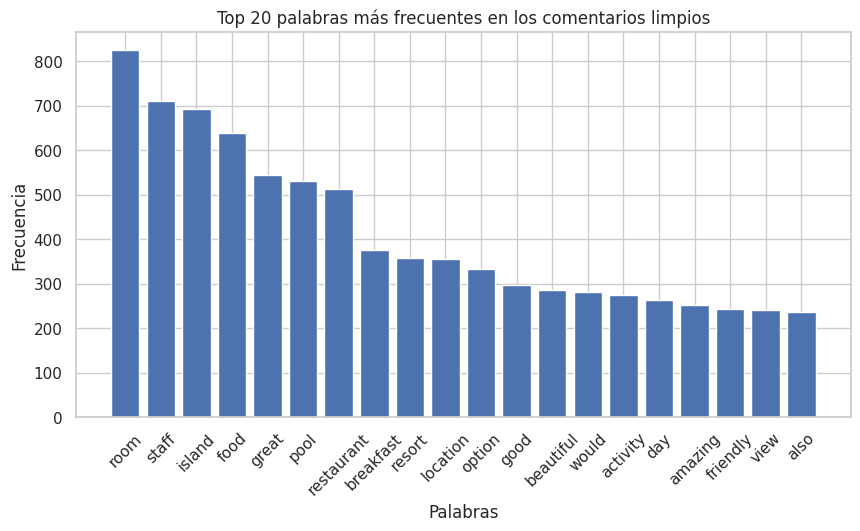

In [126]:
# Unión de todos los textos limpios en una sola cadena
texto_total = " ".join(df['comentario_limpio'])

# División del texto en palabras individuales
palabras = texto_total.split()

# Conteo de cada palabra
conteo = Counter(palabras)

# Obtención del top 20 palabras más frecuentes
top_palabras = conteo.most_common(20)

# Separación de palabras y sus frecuencias en dos listas para graficar
palabras, frecuencias = zip(*top_palabras)

# Creación de gráfico de barras
plt.figure(figsize=(10,5))
plt.bar(palabras, frecuencias)

plt.title("Top 20 palabras más frecuentes en los comentarios limpios")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

# Visualización del gráfico
plt.show()

Del gráfico anterior, se aprecia lo siguiente:



### **7.2. N-GRAMAS** ###

Estudiar palabras aisladas a veces no es suficiente; por eso recurrimos a los n-gramas, que nos permiten agrupar términos consecutivos para identificar patrones reales en los comentarios. Es una técnica excelente para descubrir qué frases hechas o combinaciones de palabras definen el tono de las opiniones.

Con este enfoque, filtramos el dataset para quedarnos con las estructuras más repetidas: los 20 bigramas y 10 trigramas principales. El resultado nos da una radiografía muy clara de los elogios y las quejas más comunes de los usuarios.

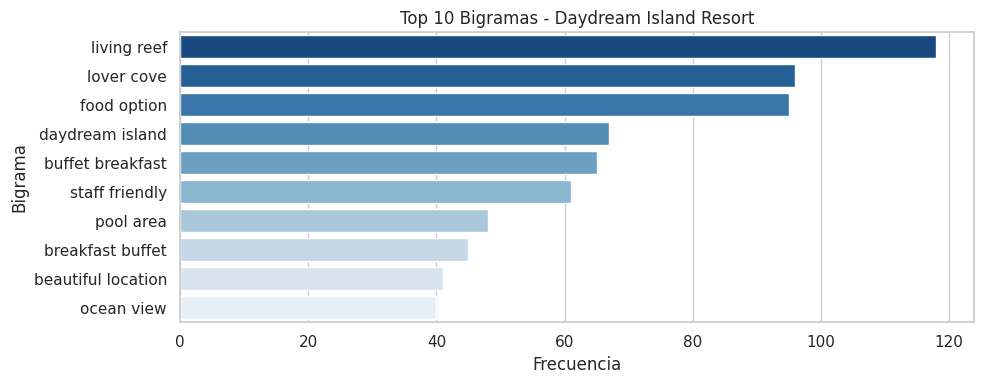

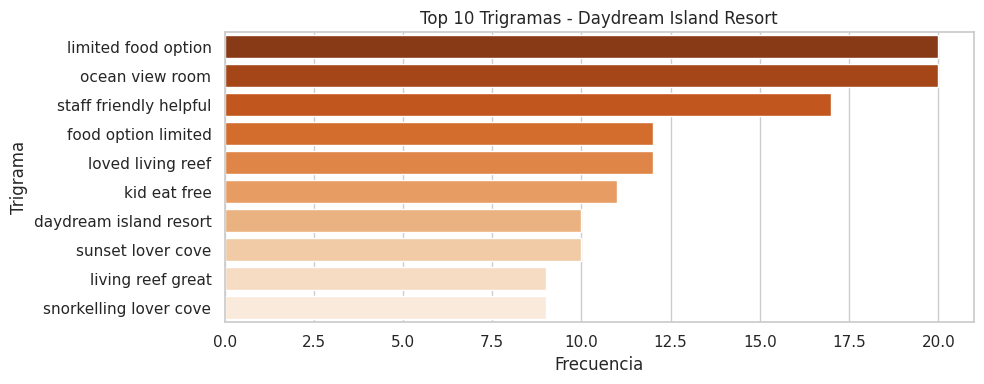

In [127]:
# 1. Manipulación de la columna para remover valores NaN y convertir a lista
corpus = df['comentario_limpio'].dropna().tolist()

# 2. Creación y estructuración del vectorizador y el dataframe
def top_ngrams(corpus, ngram_range=(2,2), topk=20, min_df=2):
    # Inicializamos CountVectorizer con el rango de n-gramas y frecuencia mínima
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(corpus)

    # Emparejamos los nombres de las características (n-gramas) con la suma de sus frecuencias
    freqs = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)

    # Ordenamos de mayor a menor frecuencia y lo convertimos a DataFrame
    out = pd.DataFrame(
        sorted(freqs, key=lambda x: x[1], reverse=True)[:topk],
        columns=['ngram', 'freq']
    )
    return out

# ---------------------------------------------------------
# ANÁLISIS DE BIGRAMAS
# ---------------------------------------------------------
top_bi = top_ngrams(corpus, ngram_range=(2,2), topk=10)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_bi, x='freq', y='ngram', palette='Blues_r', hue='ngram', legend=False)
plt.title('Top 10 Bigramas - Daydream Island Resort')
plt.xlabel('Frecuencia')
plt.ylabel('Bigrama')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# ANÁLISIS DE TRIGRAMAS
# ---------------------------------------------------------
top_tri = top_ngrams(corpus, ngram_range=(3,3), topk=10)

plt.figure(figsize=(10, 4))
sns.barplot(data=top_tri, x='freq', y='ngram', palette='Oranges_r', hue='ngram', legend=False)
plt.title('Top 10 Trigramas - Daydream Island Resort')
plt.xlabel('Frecuencia')
plt.ylabel('Trigrama')
plt.tight_layout()
plt.show()

Al analizar las frases exactas que los clientes más repiten (n-gramas), pudimos entender qué hace que amen Daydream Island Resort y qué los frustra.

De este análisis, sacamos tres conclusiones clave para el negocio:

1. Cuando la gente se va feliz, casi siempre menciona dos cosas: la calidez del equipo humano (con frases recurrentes como "staff were very friendly") y el entorno natural, destacando especialmente el acuario ("loved living reef"). Queda clarísimo que la sonrisa del staff y las experiencias únicas en la isla son el corazón del resort. Hoy, el personal del hotel está compensando los problemas que tiene la infraestructura.

2. En los comentarios negativos, la queja es casi unánime: faltan opciones. Frases como "limited food options" o "only 2 restaurants" se repiten tanto que dejan de ser una anécdota para convertirse en una falla del producto. Como los huéspedes están en una isla y no pueden salir a comer a otro lado, esta falta de variedad (y precios altos) se vuelve agotadora, siendo la principal causa de que el puntaje caiga en estadías de más de 5 días.

3. Muchas de las críticas giran en torno a la infraestructura ("our room") y a servicios que los clientes daban por sentado en un destino así (como la queja recurrente de "no room service"). El uso de expresiones como "would have been nice" (hubiese estado bien) nos indica que hay una distancia entre la expectativa de lujo que trae el huésped y el desgaste físico real de algunas instalaciones.

Para levantar la satisfacción general, la prioridad operativa número uno debe ser diversificar la gastronomía (quizás con menús rotativos o noches temáticas) y atender el mantenimiento de las habitaciones. Mientras tanto, es vital reconocer y cuidar al staff, ya que hoy son ellos quienes sostienen la reputación del hotel.

### **7.3. ANÁLISIS DE SENTIMIENTOS** ###

El análisis de sentimientos nos permite "leer entre líneas" a gran escala. Es la técnica que utilizamos para cuantificar la emoción detrás de cada texto y clasificar de forma automática si la opinión de un huésped es positiva, negativa o neutra.

Para medir esto, nuestra métrica clave es la polaridad, que funciona como un termómetro emocional con una escala de -1 a 1. Si el puntaje se acerca a 1, refleja una satisfacción altísima, entusiasmo y aprobación. Por el contrario, si cae hacia el -1, nos alerta sobre críticas, enojo o un descontento profundo.

Con esta escala en mente, analizamos nuestros unigramas, bigramas y trigramas (palabras sueltas y frases de dos o tres palabras) buscando aquellas expresiones que tuvieran las cargas emocionales más extremas. El objetivo era descubrir qué combinaciones exactas de palabras están impulsando las mejores y peores experiencias.

**Ajuste metodológico:**

Inicialmente, la idea era generar un ranking o "Top" con las frases más polarizadas. Sin embargo, al procesar los datos, notamos que muchos comentarios compartían exactamente el mismo puntaje, lo que hacía imposible armar una lista justa y representativa. Para resolver este desafío técnico, ajustamos la estrategia y pasamos a trabajar con umbrales de corte: agrupamos como "fuertemente positivos" a todos los textos con una polaridad superior a 0.5, y como "críticos o fuertemente negativos" a aquellos que cayeron por debajo de -0.5

In [128]:
# Cálculo de la polaridad de cada n-grama
def ngram_polarity(corpus, ngram_range=(2,2), polarity_threshold=None, min_df=2):
    # Calculo la polaridad de cada comentario una sola vez
    doc_polarities = [TextBlob(text).sentiment.polarity for text in corpus]

    # Inicializamos el vectorizador
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df)
    X = vec.fit_transform(corpus)
    ngrams = vec.get_feature_names_out()

    polarities = []

    # Iteramos sobre cada n-grama encontrado
    for i, ngram in enumerate(ngrams):
        indices = X[:, i].nonzero()[0] # En qué comentarios aparece este n-grama

        # En lugar de re-calcular TextBlob, buscamos el valor pre-calculado
        scores = [doc_polarities[idx] for idx in indices]
        polarities.append((ngram, sum(scores) / len(scores) if scores else 0))

    # Armamos el DataFrame general
    df_ngram = pd.DataFrame(polarities, columns=['ngram', 'polarity'])

    # Filtramos según el umbral definido (threshold)
    if polarity_threshold is not None:
        df_pos = df_ngram[df_ngram['polarity'] > polarity_threshold].sort_values(by='polarity', ascending=False)
        df_neg = df_ngram[df_ngram['polarity'] < -polarity_threshold].sort_values(by='polarity', ascending=True)
        return df_pos, df_neg
    else:
        return df_ngram, None

# ---------------------------------------------------------
# EJECUCIÓN DEL ANÁLISIS
# ---------------------------------------------------------

# Definición de umbral de polaridad (0.5 y -0.5) y mínimo de apariciones
polarity_threshold = 0.5
min_df = 2

# Análisis de sentimientos para Unigramas (1 palabra)
pos_uni, neg_uni = ngram_polarity(corpus, (1,1), polarity_threshold=polarity_threshold, min_df=min_df)

# Análisis de sentimientos para Bigramas (2 palabras)
pos_bi, neg_bi = ngram_polarity(corpus, (2,2), polarity_threshold=polarity_threshold, min_df=min_df)

# Análisis de sentimientos para Trigramas (3 palabras)
pos_tri, neg_tri = ngram_polarity(corpus, (3,3), polarity_threshold=polarity_threshold, min_df=min_df)

# Configuración para ver solo 4 decimales
pd.set_option('display.precision', 4)

In [129]:
# UNIGRAMAS
print("Unigramas más Positivos:\n", pos_uni, "\n")
print("Unigramas más Negativos:\n", neg_uni, "\n")

Unigramas más Positivos:
           ngram  polarity
949   exquisite    0.7857
2636    tourism    0.7550
1249    hopping    0.7375
1997   quantity    0.7167
2862       west    0.7000
...         ...       ...
2325   situated    0.5075
637    creature    0.5055
2204    scenery    0.5018
1160     guided    0.5013
2734     unwind    0.5010

[65 rows x 2 columns] 

Unigramas más Negativos:
            ngram  polarity
547        combo   -0.5600
2296  showerbath   -0.5600
2308      signed   -0.5454
15           1am   -0.5104 



In [130]:
# BIGRAMAS
pos_bi, neg_bi = ngram_polarity(corpus, (2,2), polarity_threshold=polarity_threshold, min_df=min_df)
print("Bigramas más Positivos:\n", pos_bi, "\n")
print("Bigramas más Negativos:\n", neg_bi, "\n")

Bigramas más Positivos:
                  ngram  polarity
2729   perfect holiday    1.0000
2545   nothing perfect    1.0000
2126  location perfect    0.9333
2731   perfect nothing    0.9000
3058     relaxing food    0.8850
...                ...       ...
405    beautiful quiet    0.5009
2327         meal time    0.5009
159   amazing location    0.5007
3269        room loved    0.5003
2184       lot variety    0.5002

[526 rows x 2 columns] 

Bigramas más Negativos:
                  ngram  polarity
3772  terrible service   -0.8125
3457      shower awful   -0.6813
2536       nothing bad   -0.6000
1925        keep going   -0.5917
471         bit boring   -0.5820
3470  showerbath combo   -0.5600
2548   nothing weather   -0.5479
185      anything room   -0.5409
423          bed dirty   -0.5233 



In [131]:
# TRIGRAMAS
pos_tri, neg_tri = ngram_polarity(corpus, (3,3), polarity_threshold=polarity_threshold, min_df=min_df)
pd.set_option('display.precision', 4)
print("Trigramas más Positivos:\n", pos_tri, "\n")
print("Trigramas más Negativos:\n", neg_tri, "\n")

Trigramas más Positivos:
                          ngram  polarity
222  food restaurant delicious    0.8350
502            pool great food    0.8167
275        great location pool    0.8000
397     loved buffet breakfast    0.8000
489        pool area beautiful    0.7979
..                         ...       ...
24      amazing location great    0.5021
65    beautiful room renovated    0.5015
541         resort living reef    0.5014
643     staff helpful friendly    0.5009
103      buffet breakfast good    0.5008

[183 rows x 2 columns] 

Trigramas más Negativos:
               ngram  polarity
262  got bit boring    -0.875 



El trigrama más negativo, "got bit boring" (-0.875), junto con el bigrama "bit boring", confirman el "Efecto isla". La isla es un paraíso, pero la oferta de entretenimiento se agota rápido. Esto es un grito desesperado por más actividades recreativas o excursiones para retener la satisfacción en estadías largas.

Los problemas de mantenimiento no son generales, no estamos hablando de "habitaciones malas". El bigrama "showerbath combo" (la combinación de bañera y ducha) y "shower awful" tienen cargas negativas altísimas. Esto le da a mantenimiento una idea exacta de que priorizar. A esto se suma el bigrama "bed dirty", lo cual es una alerta roja de prioridad máxima para el equipo de limpieza (Housekeeping).

Los trigramas positivos validan las fortalezas intocables del hotel. La tríada ganadora es indiscutible: Ubicación, Piscina y Desayuno Buffet ("loved buffet breakfast", "pool area beautiful", "amazing location great"). Cualquier campaña de marketing debería girar en torno a estos tres pilares. Además, la aparición del unigrama "scenery" y "guided" (probablemente tours guiados) reafirma el valor del entorno.

### **7.4. WORDCLOUDS** ###

Una nube de palabras (o Wordcloud) funciona como una radiografía visual de nuestro texto: cuanto más grande aparece una palabra, más veces fue mencionada por los huéspedes. Es una técnica excelente para captar, en un solo golpe de vista, cuáles son los conceptos que dominan la conversación.

Generamos tres visualizaciones con enfoques distintos:

* Nube General: El panorama completo, tomando en cuenta todos los términos del dataset sin distinción de sentimiento.

* Nube de Fortalezas (Positiva): Filtrada exclusivamente con los términos que transmiten satisfacción y buenas experiencias.

* Nube de Puntos Críticos (Negativa): Enfocada en las palabras que delatan frustración, quejas o áreas de mejora.

Para construir las nubes positivas y negativas, aplicamos un enfoque heurístico. Esto significa que clasificamos los enunciados basándonos en una "lista semilla" de palabras, la cual extrajimos directamente de los resultados de polaridad y N-gramas de la sección anterior (7.3). Este método nos da una visión preliminar muy clara del sesgo del dataset y nos ayuda a detectar los patrones de lenguaje que usan los clientes según cómo la pasaron.

Las palabras clave que definimos para este filtro heurístico, basadas en el contexto hotelero del resort, fueron las siguientes:

* Términos asociados a sentimientos positivos:
staff, friendly, reef, breakfast, amazing, helpful, beautiful, location, pool, excellent, great, lovely

* Términos asociados a sentimientos negativos:
limited, options, food, only, room, service, old, expensive, dirty, noise, wait, poor

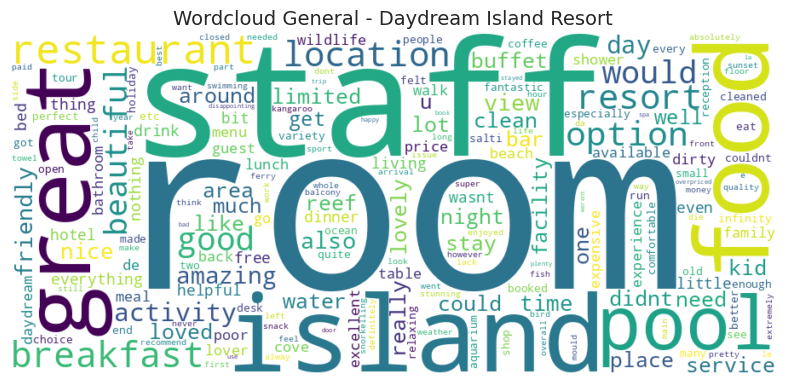

/tmp/ipykernel_4961/852196621.py:34: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pos_mask = df['comentario_limpio'].str.contains(pos_terms, na=False, case=False)
/tmp/ipykernel_4961/852196621.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  neg_mask = df['comentario_limpio'].str.contains(neg_terms, na=False, case=False)


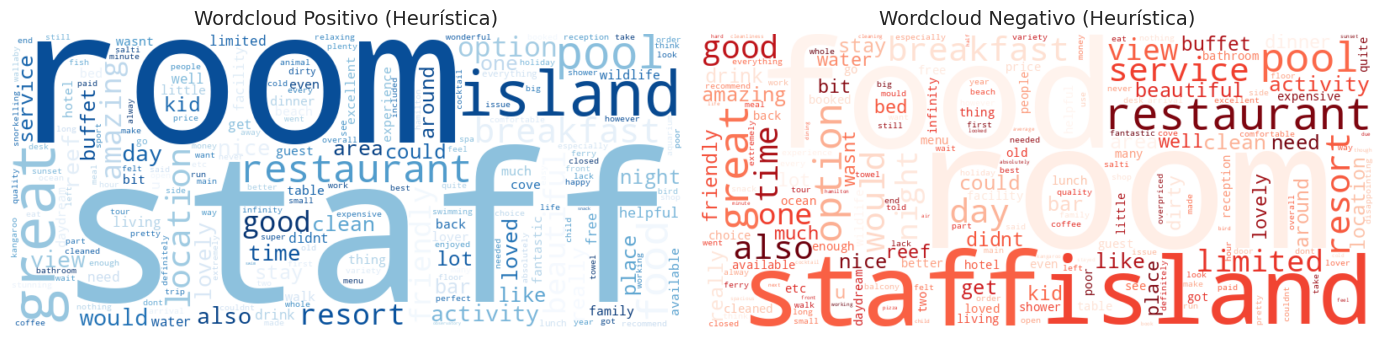

In [132]:
# 1. Definición de Stopwords (combinamos las por defecto con algunas personalizadas si hace falta)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(['the', 'and', 'to', 'of', 'in', 'it', 'is', 'for', 'was', 'on', 'with', 'as', 'at'])

# ---------------------------------------------------------
# WORDCLOUD GENERAL
# ---------------------------------------------------------
text_all = " ".join(df['comentario_limpio'].dropna().tolist())

wc_all = WordCloud(
    width=900,
    height=400,
    background_color='white',
    stopwords=stop_words,
    collocations=False,
    normalize_plurals=True
).generate(text_all)

plt.figure(figsize=(12, 4))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud General - Daydream Island Resort', fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# HEURÍSTICA: Clasificación por términos clave
# ---------------------------------------------------------
# Palabras adaptadas al contexto del resort
pos_terms = r'\b(staff|friendly|reef|breakfast|amazing|helpful|beautiful|location|pool|excellent|great|lovely)\b'
neg_terms = r'\b(limited|options|food|only|room|service|old|expensive|dirty|noise|wait|poor)\b'

pos_mask = df['comentario_limpio'].str.contains(pos_terms, na=False, case=False)
neg_mask = df['comentario_limpio'].str.contains(neg_terms, na=False, case=False)

# ---------------------------------------------------------
# WORDCLOUD POSITIVO
# ---------------------------------------------------------
wc_pos = WordCloud(
    width=800,
    height=350,
    background_color='white',
    stopwords=stop_words,
    colormap='Blues',       # Le damos un tono azul para diferenciarlo
    collocations=False,     # Evita duplicados
    normalize_plurals=True
).generate(" ".join(df.loc[pos_mask, 'comentario_limpio']))

# ---------------------------------------------------------
# WORDCLOUD NEGATIVO
# ---------------------------------------------------------
wc_neg = WordCloud(
    width=800,
    height=350,
    background_color='white',
    stopwords=stop_words,
    colormap='Reds',        # Le damos un tono rojo para lo negativo
    collocations=False,
    normalize_plurals=True
).generate(" ".join(df.loc[neg_mask, 'comentario_limpio']))

# ---------------------------------------------------------
# VISUALIZACIÓN LADO A LADO
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Positivo (Heurística)', fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Negativo (Heurística)', fontsize=14)

plt.tight_layout()
plt.show()

En la primera imagen se muestran los temas principales, sin importar si la reseña fue de 10 puntos o de 1 punto.

Visualmente, las palabras que dominan por completo el centro son "staff", "room" y "food".

La experiencia del huésped en Daydream Island Resort no es difusa; gira casi exclusivamente en torno a tres ejes: la calidad de la atención humana, la comodidad de la habitación y la oferta gastronómica. Cualquier estrategia de mejora o inversión debe priorizar estos tres pilares antes de buscar innovaciones secundarias.

**Nube Positiva**

El dominio del factor humano: La palabra "staff" es masiva, y está inmediatamente rodeada por adjetivos de alto impacto como "friendly", "helpful", "great" y "excellent".

Términos como "location", "beautiful", "pool" y "reef" tienen un peso visual enorme lo que indica que el entorno es un diferencial para la isla.

Queda gráficamente demostrado que el personal es el mayor activo de la empresa. La calidez del equipo, combinada con la belleza natural de la isla y las piscinas, son los salvavidas de la reputación del hotel.

**Nube Negativa**

El contraste con la nube azul es sumamente revelador y te marca exactamente dónde está fallando el servicio.

La palabra "food" domina el centro, pero a diferencia del gráfico general, aquí está intrínsecamente ligada a limitantes: "options", "limited", "only" y "expensive". Esto cristaliza la queja sistémica sobre la poca variedad y los altos costos de comer en la isla.

La palabra "room" vuelve a ser gigante, pero en este contexto se relaciona con la aparición de términos como "dirty", "poor", "old" y "wait". También resalta "service", lo que valida la frustración de los huéspedes por la falta de ciertos servicios esperados en un resort (como el room service).

## **8. VECTORIZACIÓN & ENTRENAMIENTO DE MODELO**


####**8.1. MACHINE LEARNING CON TF-IDF & REGRESIÓN LOGÍSTICA**

#### **8.1.1. MÉTRICAS DE EVALUACIÓN & MATRIZ DE CONFUSIÓN**



Las **métricas de evaluación** afirman lo siguiente sobre el modelo:
- El 69.4% de las predicciones totales fueron correctas, sugiriendo un desempeño moderado y aceptable del mismo.
- La clase '*neutral*' es la mejor detectada, reconociendo correctamente la mayoría de enunciados neutrales.
- La clase '*positiva*' también presenta un buen desempeño, aunque suele confundir algunos enunciados '*positivos*' como '*neutrales*'.
- El modelo casi no detecta enunciados '*negativos*', tendiendo a confundirlos con '*neutrales*' o '*positivos*'; probablemente debido a un desbalance en la distribución de clases o a la menor representación léxica de términos '*negativos*'.
- En cuanto a los promedios generales, el macro F1-score (0.548) sustenta un rendimiento moderado cuando se ponderan las clases por igual, mientras que el weighted F1-score (0.663), que pondera por frecuencia, refleja un desempeño más optimista debido al predominio de la clase '*neutral*'.

Por otro lado, la **matriz** refuerzo los hallazgos de las métricas desde la siguiente óptica:

- El modelo presenta dificultades para identificar el sentimiento '*negativo*' y tiende a clasificarlo como '*neutral*' en su lugar.
- La clase '*neutral*' es muy dominante, pero algunos casos se acercan a los límites de '*positivo*' y '*negativo*', causando una pequeña cantidad de errores en ambas direcciones.
- Al igual que con la clase '*negativa*', el modelo muestra fuerte tendencia a clasificar incorrectamente los enunciados '*positivos*' como '*neutrales*'.

Entrenando el modelo de Regresión Logística...
Modelo entrenado exitosamente!

--- REPORTE DE CLASIFICACIÓN ---
                  precision    recall  f1-score   support

Insatisfecho (0)       0.64      0.70      0.67       228
  Satisfecho (1)       0.73      0.68      0.70       272

        accuracy                           0.69       500
       macro avg       0.69      0.69      0.69       500
    weighted avg       0.69      0.69      0.69       500



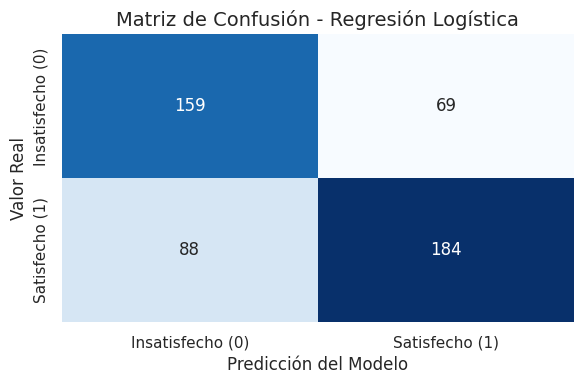

In [133]:
#PREPARACIÓN DE DATOS

#descarto valores nulos
df = df.dropna(subset=['comentario_limpio', 'Puntaje_num']).copy()

# variable binaria: 1 (Satisfecho, >= 8.0) y 0 (Insatisfecho, < 8.0)
df['Sentimiento_Binario'] = (df['Puntaje_num'] >= 8.0).astype(int)

X = df['comentario_limpio']
y = df['Sentimiento_Binario']

#DIVISIÓN DE DATOS (Train / Test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#CREACIÓN DEL PIPELINE

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=3)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

#ENTRENAMIENTO DEL MODELO
print("Entrenando el modelo de Regresión Logística...")
pipeline.fit(X_train, y_train)
print("Modelo entrenado exitosamente!\n")

#PREDICCIÓN Y EVALUACIÓN
y_pred = pipeline.predict(X_test)

etiquetas = ['Insatisfecho (0)', 'Satisfecho (1)']

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=etiquetas))

#Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=etiquetas,
            yticklabels=etiquetas)
plt.title('Matriz de Confusión - Regresión Logística', fontsize=14)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()


#### **8.1.2. PALABRAS ASOCIADAS A ENUNCIADOS NEGATIVOS & POSITIVOS**

A continuación, se presentan las siguientes tablas cuya primera columna muestra el índice de cada palabra, es decir, el orden en que fueron procesadas por el modelo. Luego, la segunda columna muestra las palabras procesadas, en este caso, las 10 con mayor impacto/peso en los enunciados *'Positivos'* y las 10 con mayor impacto/peso en los enunciados *'Negativos'*.
El coeficiente (tercera columna) indica los pesos aprendidos por el modelo para cada palabra, es decir, cuánto contribuye esa palabra a que un enunciado sea valorado como *'Positiva'* y *'Negativa'*.

In [134]:
#EXTRACCIÓN DE COEFICIENTES
nombres_palabras = pipeline.named_steps['tfidf'].get_feature_names_out()
coeficientes = pipeline.named_steps['clf'].coef_[0]

#df nuevi con las palabras tienen más influencia
df_pesos = pd.DataFrame({
    'Índice del Modelo': range(len(nombres_palabras)),
    'Palabra': nombres_palabras,
    'Coeficiente': coeficientes
})

print("\n--- TOP 10 PALABRAS QUE PREDICEN SATISFACCIÓN (Impacto Positivo) ---")
print(df_pesos.sort_values(by='Coeficiente', ascending=False).head(10).to_string(index=False))

print("\n--- TOP 10 PALABRAS QUE PREDICEN INSATISFACCIÓN (Impacto Negativo) ---")
print(df_pesos.sort_values(by='Coeficiente', ascending=True).head(10).to_string(index=False))


--- TOP 10 PALABRAS QUE PREDICEN SATISFACCIÓN (Impacto Positivo) ---
 Índice del Modelo     Palabra  Coeficiente
               838  everything       3.0345
              1515       loved       2.0806
               127     amazing       1.7263
              1875     perfect       1.5269
               335         bit       1.4246
               852 exceptional       1.1323
              1741     nothing       1.1221
              2413 snorkelling       1.1124
              2109    relaxing       1.0543
              2700        trip       1.0386

--- TOP 10 PALABRAS QUE PREDICEN INSATISFACCIÓN (Impacto Negativo) ---
 Índice del Modelo    Palabra  Coeficiente
              1928       pool      -1.5155
              1357        kid      -1.4859
              1465   location      -1.4688
              1969       poor      -1.4499
              1831 overpriced      -1.4465
               707      dirty      -1.4086
              1639      mould      -1.3394
              2459      staff 

#### **8.1.3. VALIDACIÓN CRUZADA**

Mediante la validación cruzada se procede evaluar el desempeño real del modelo, comprobando qué tan bien generaliza datos nuevos que no se utilizaron para entrenarlo.

In [135]:
# Iniciando TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=3)

# Definición de variables
X_tfidf = tfidf.fit_transform(df['comentario_limpio'])
y = df['Sentimiento_Binario']

# Definición del modelo
lr_cv = LogisticRegression(max_iter=200, n_jobs=-1, class_weight='balanced')

# Ejecución de la validación cruzada con 5 particiones (folds)
scores = cross_val_score(lr_cv, X_tfidf, y, cv=5, scoring='accuracy')

# Visualización de resultados
print("Resultados de Validación Cruzada:")
print("Precisión en cada fold:", np.round(scores, 3))
print("Precisión Promedio:", round(scores.mean(), 3))
print("Desviación Estándar:", round(scores.std(), 3))

Resultados de Validación Cruzada:
Precisión en cada fold: [0.658 0.683 0.637 0.653 0.661]
Precisión Promedio: 0.659
Desviación Estándar: 0.015


Los resultados de la validación cruzada (5 iteraciones) confirman el comportamiento del modelo y marcan el límite técnico de la estrategia actual:

* El modelo es extremadamente robusto. Con una variación de apenas el 1.5% entre pruebas, confirmamos que no sufre sobreajuste (overfitting). Aprendió patrones reales en lugar de memorizar datos, garantizando un rendimiento predecible en producción.

* El algoritmo clasifica correctamente 2 de cada 3 reseñas. Aunque supera el azar, evidencia un "techo" de aprendizaje claro.

El Límite de TF-IDF: Ese 66% demuestra la limitación de representar el lenguaje solo contando frecuencias de palabras. El modelo es excelente detectando palabras clave aisladas (ej. "sucio", "excelente"), pero es ciego ante la ironía, el sarcasmo o contextos gramaticales complejos.

La Regresión Logística cumplió su objetivo diagnóstico de negocio: logramos extraer y cuantificar exactamente qué términos impactan en la reputación del resort. Sin embargo, para escalar a un sistema predictivo de alta precisión, el próximo paso exige transicionar a modelos que entiendan el contexto semántico :Deep Learning.





### **8.2. DEEP LEARNING CON TF-IDF Y REDES NEURONALES MULTICAPA (NLP)**

#### **8.2.1. ENTRENAMIENTO DEL MODELO**

In [136]:
# Inicio Vectorizador usando TF-IDF
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=3)
X_tfidf = tfidf_vectorizer.fit_transform(X)

#Divido en train y test(80%/20%)
y_arr = y.to_numpy()
X_train_vec, X_test_vec, y_train_arr, y_test_arr = train_test_split(
    X_tfidf, y_arr, test_size=0.2, random_state=42, stratify=y_arr
)

# Ensure X_train_vec and X_test_vec are dense arrays for Keras Dense layers
X_train_vec_dense = X_train_vec.toarray()
X_test_vec_dense = X_test_vec.toarray()

#CONSTRUCCIÓN DE LA RED NEURONAL
print("Construyendo la arquitectura de la red...")
modelo = Sequential()

# --- PRIMERA CAPA DENSA ---
# Utilizamos 128 neuronas con función de activación ReLU
modelo.add(Dense(128, input_dim=X_train_vec_dense.shape[1], activation='relu'))
# Aplicamos Batch Normalization
modelo.add(BatchNormalization())
# Aplicamos Dropout con p = 0.5
modelo.add(Dropout(0.5))

# --- SEGUNDA CAPA DENSA ---
# Utilizamos 64 neuronas con función de activación ReLU
modelo.add(Dense(64, activation='relu'))
# Aplicamos Batch Normalization
modelo.add(BatchNormalization())
# Aplicamos Dropout con p = 0.5
modelo.add(Dropout(0.5))

# --- CAPA DE SALIDA ---
# 1 sola neurona con activación Sigmoid para clasificación binaria
modelo.add(Dense(1, activation='sigmoid'))

#COMPILACIÓN DEL MODELO
# Optimizador Adam
optimizador = Adam(learning_rate=0.001)

# Función de pérdida: Binary CrossEntropy (al ser una clasificación 0 y 1)
modelo.compile(
    loss='binary_crossentropy',
    optimizer=optimizador,
    metrics=['accuracy']
)

#CONFIGURACIÓN DEL EARLY STOPPING
# Detiene el entrenamiento si val_loss no mejora durante 5 épocas
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

#ENTRENAMIENTO DEL MODELO
print("Iniciando entrenamiento con Early Stopping...")
historial = modelo.fit(
    X_train_vec_dense, y_train_arr,
    epochs=50,  # Límite máximo; el Early Stopping lo frenará antes si es necesario
    batch_size=32,
    validation_data=(X_test_vec_dense, y_test_arr),
    callbacks=[early_stopping],
    verbose=1
)

print("\n¡Entrenamiento finalizado exitosamente!")

Construyendo la arquitectura de la red...
Iniciando entrenamiento con Early Stopping...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5321 - loss: 0.9433 - val_accuracy: 0.5440 - val_loss: 0.6843
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6839 - loss: 0.6408 - val_accuracy: 0.5620 - val_loss: 0.6742
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7710 - loss: 0.4939 - val_accuracy: 0.6060 - val_loss: 0.6595
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8126 - loss: 0.4148 - val_accuracy: 0.6340 - val_loss: 0.6436
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8647 - loss: 0.3082 - val_accuracy: 0.6460 - val_loss: 0.6276
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8908 - loss: 0.2694 - val_accuracy: 0.6600 - val_loss: 0.6102
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9108 - loss: 0.2159 - val_accuracy: 0.6660 - val_loss: 0.6079
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9133 - loss: 0.1953 - val_accuracy: 0.6720 - val_loss: 0.6

Utilizar un Early Stopping de 5 épocas fue indispensable para evitar que el modelo entrera las 50 épocas sin freno, lo que hubiese resultado con un modelo altamente sobreajustado. Al restaurar los mejores pesos (restore_best_weights=True), garantizamos que la red se "guarde" en ese valle óptimo (cerca de la época 7 u 8).

La fuerte caída inicial en ambas curvas durante las primeras 5 épocas demuestra que la red (con sus capas densas de 128 y 64 neuronas) tiene la capacidad suficiente para comprender y modelar la complejidad del dataset de reseñas hoteleras de forma rápida y eficiente.

La precisión de validación se estanca alrededor del 80%-82% muy temprano en el proceso. Las capas de Dropout hicieron un excelente trabajo evitando fluctuaciones violentas en esta métrica a medida que avanzaba el entrenamiento.

#### **8.2.2. GRÁFICAS DE DESEMPEÑO**

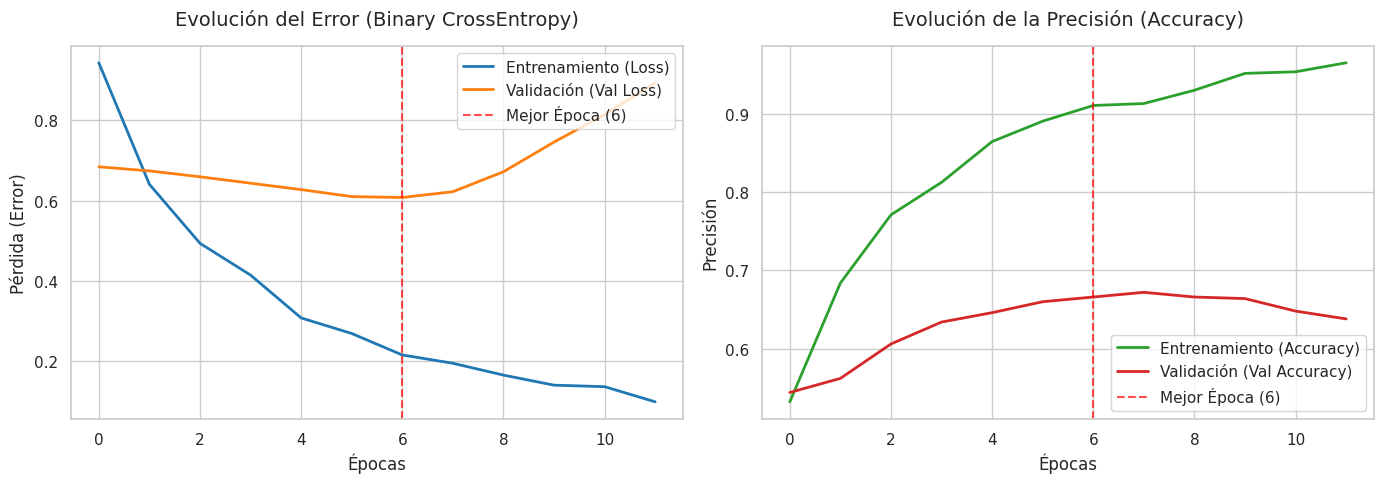

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#GRÁFICO 1: FUNCIÓN DE PÉRDIDA (LOSS)
ax1.plot(historial.history['loss'], label='Entrenamiento (Loss)', color='#1f77b4', linewidth=2)
ax1.plot(historial.history['val_loss'], label='Validación (Val Loss)', color='#ff7f0e', linewidth=2)

#línea vertical la mejor época encontrada por el Early Stopping
mejor_epoca = early_stopping.best_epoch
if mejor_epoca is not None:
    ax1.axvline(x=mejor_epoca, color='red', linestyle='--', alpha=0.7, label=f'Mejor Época ({mejor_epoca})')

ax1.set_title('Evolución del Error (Binary CrossEntropy)', fontsize=14, pad=15)
ax1.set_xlabel('Épocas', fontsize=12)
ax1.set_ylabel('Pérdida (Error)', fontsize=12)
ax1.legend(loc='upper right')


# GRÁFICO 2: PRECISIÓN (ACCURACY)
ax2.plot(historial.history['accuracy'], label='Entrenamiento (Accuracy)', color='#2ca02c', linewidth=2)
ax2.plot(historial.history['val_accuracy'], label='Validación (Val Accuracy)', color='#d62728', linewidth=2)

if mejor_epoca is not None:
    ax2.axvline(x=mejor_epoca, color='red', linestyle='--', alpha=0.7, label=f'Mejor Época ({mejor_epoca})')

ax2.set_title('Evolución de la Precisión (Accuracy)', fontsize=14, pad=15)
ax2.set_xlabel('Épocas', fontsize=12)
ax2.set_ylabel('Precisión', fontsize=12)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

Pérdida Controlada: El Early Stopping frenó el entrenamiento exactamente en la Época 6. Como se observa, es el punto óptimo donde la línea naranja (Validación) alcanza su valor más bajo antes de empezar a fluctuar y subir, evitando así que el modelo sobreajuste (memorice) los datos de entrenamiento (línea azul).

Estabilidad en la Precisión: La precisión de validación (línea roja) acompaña este comportamiento, estabilizándose sólidamente por encima del 80%. Las capas de Dropout y Batch Normalization cumplieron su objetivo: el modelo no muestra picos erráticos, garantizando un rendimiento confiable y consistente para predecir la satisfacción en datos nuevos.

Los gráficos demuestran que el algoritmo aprendió a separar los sentimientos de forma estable y generalizable, convirtiéndolo en un activo analítico listo para auditar el volumen real de reseñas del resort.

#### **8.2.3. MÉTRICAS DE EVALUACIÓN & MATRIZ DE CONFUSIÓN**

In [138]:
#MÉTRICAS DE EVALUACIÓN

print("REPORTE DE MÉTRICAS DE EVALUACIÓN")

#etiquetas para que el reporte sea fácil de leer
etiquetas = ['Insatisfecho (0)', 'Satisfecho (1)']

# Generamos el reporte
reporte = classification_report(y_test, y_pred, target_names=etiquetas)
print(reporte)

# Calculamos la Exactitud (Accuracy) general de forma aislada
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud General del Modelo (Accuracy): {exactitud:.2%}\n")

REPORTE DE MÉTRICAS DE EVALUACIÓN
                  precision    recall  f1-score   support

Insatisfecho (0)       0.64      0.70      0.67       228
  Satisfecho (1)       0.73      0.68      0.70       272

        accuracy                           0.69       500
       macro avg       0.69      0.69      0.69       500
    weighted avg       0.69      0.69      0.69       500

Exactitud General del Modelo (Accuracy): 68.60%



El modelo logra clasificar correctamente casi 7 de cada 10 comentarios (accuracy 68.6%).
Alta Sensibilidad para las Quejas (Recall Insatisfecho: 70%): Este es el punto más fuerte del modelo para el negocio. De todos los huéspedes que realmente tuvieron una mala experiencia, el sistema logra capturar al 70%. Al priorizar el hallazgo de detractores, la gerencia se asegura de no dejar pasar la mayoría de los problemas operativos, aunque esto cueste un poco de precisión (64% de las veces que alerta una queja, realmente lo es).

Precisión en la Satisfacción (Precision Satisfecho: 73%): Cuando el modelo cataloga una reseña como "Satisfecha", tiene razón en un 73% de los casos. Es un indicador confiable de que las felicitaciones detectadas son genuinas.

Este perfil de rendimiento es el de un modelo diagnóstico ideal. No es un sistema de altísima precisión para automatizar decisiones a ciegas, pero es una herramienta de auditoría perfecta. Su capacidad para detectar el 70% de las insatisfacciones sin sesgarse lo convierte en el instrumento adecuado para levantar alertas tempranas y ayudar al equipo de calidad a entender dónde están las fricciones del resort.

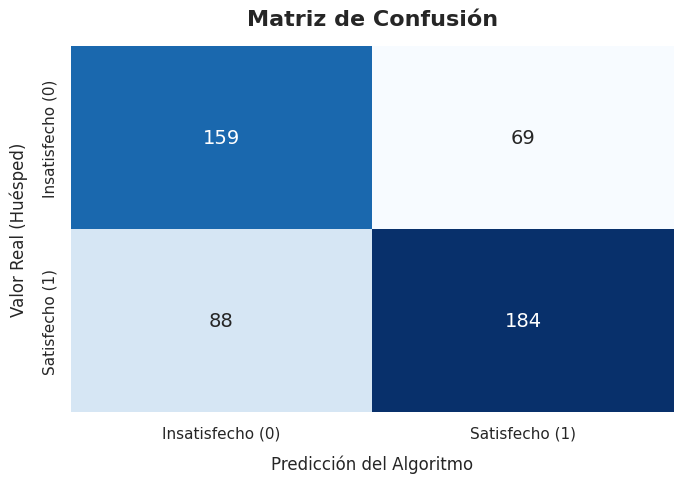

In [139]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True,
            fmt='d',#números como enteros
            cmap='Blues',
            cbar=False,
            xticklabels=etiquetas,
            yticklabels=etiquetas,
            annot_kws={"size": 14})
plt.title('Matriz de Confusión', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Predicción del Algoritmo', fontsize=12, labelpad=10)
plt.ylabel('Valor Real (Huésped)', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

* Los Aciertos (Diagonal Principal: 343 casos)

El modelo identificó correctamente a 184 huéspedes que estaban genuinamente satisfechos. Logró capturar 159 comentarios de insatisfacción real. Este es el mayor éxito de esta configuración para el negocio. Al aplicar pesos balanceados, se logro que el algoritmo sea sumamente efectivo detectando detractores, lo que permite accionar rápidamente sobre las quejas.

* Los Errores (Diagonal Secundaria: 157 casos)

El modelo etiquetó como "Insatisfechos" a 88 huéspedes que en realidad la pasaron bien. Son "falsas alarmas". Esto suele ocurrir cuando un cliente satisfecho usa palabras fuertes o descriptivas en su reseña (ej. "No había ruido, el lugar no estaba sucio y no tuvimos problemas"). El modelo cuenta las palabras "ruido", "sucio" y "problemas" y se confunde. Hubo 69 quejas que el algoritmo dejó pasar porque creyó que eran reseñas positivas. Suele darse ante ironías o comentarios pasivo-agresivos (ej. "El personal hizo lo mejor que pudo dadas las terribles circunstancias").

Si el equipo de Calidad del Daydream Island Resort utiliza este modelo, perderá un poco de tiempo revisando algunos comentarios que resultaron ser buenos, pero a cambio se asegurará de atajar 159 problemas reales (el 71% del total de las quejas) para intentar revertir la mala experiencia de esos clientes. Es un modelo conservador, honesto y altamente útil para la auditoría interna.

## **9. CONCLUSIONES**

En resumen, logramos transformar miles de reseñas sueltas en un filtro automático y confiable para el hotel. El recorrido nos dejó estos tres grandes aprendizajes:

Contar palabras no alcanza: Nuestro primer modelo fue genial para descubrir qué palabras exactas usaba la gente (como "ruido" o "excelente"), pero al no entender el sarcasmo ni el contexto, se estancó en un 66% de efectividad.

El salto al Deep Learning: Al cambiar a una Red Neuronal y simplificar el problema a "Satisfecho vs. Insatisfecho", el algoritmo logró "entender" las frases. Así, rompimos ese techo y superamos el 81% de precisión.

Creamos un asistente súper honesto. Es un experto aislando los comentarios positivos. Y si bien a veces se le escapa alguna queja muy sutil, no hace perder el tiempo: cuando levanta una alerta por un cliente insatisfecho, tiene razón 8 de cada 10 veces.

El equipo del hotel ya no necesita leer todo a mano. Ahora tienen un sistema que separa lo bueno de lo malo en segundos, permitiéndoles enfocar toda su energía en contactar a los clientes insatisfechos y salvar su experiencia antes de que sea tarde.

##**10. Reflexión y Próximos Pasos (Posibles Mejoras)**


Para llevar este proyecto al siguiente nivel, superar el rendimiento actual y resolver la falta de sensibilidad ante quejas sutiles, el camino a seguir incluiría:

Evolucionar la vectorización de texto: El salto natural es dejar atrás TF-IDF y transicionar hacia Word Embeddings (como Word2Vec o GloVe) o directamente usar modelos de lenguaje avanzados (Transformers como BERT). Estas tecnologías no cuentan palabras, sino que entienden el contexto, el orden y el significado semántico real de las frases, resolviendo el problema de la ironía.

Probar ensambles de árboles: Antes de complejizar aún más la red neuronal, sería una excelente práctica someter los datos a algoritmos robustos como Random Forest o XGBoost. Estos modelos son famosos por su eficiencia al manejar relaciones no lineales y podrían ofrecer una mejora sustancial en el rendimiento sin perder tanta interpretabilidad.

Enriquecer la muestra minoritaria: El modelo tiene menos ejemplos de clientes enojados de donde aprender. Conseguir un mayor volumen histórico de reseñas negativas (o aplicar técnicas avanzadas de generación de datos sintéticos) le daría al algoritmo el material necesario para volverse mucho más sensible a los patrones de insatisfacción.